In [10]:
import pandas as pd
from datetime import timedelta
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Load cleaned flood dataset
flood_df = pd.read_parquet("../../data/cleaned_major_flood_events.parquet")

# Load ERA5 dataset
era_df = pd.read_parquet("../../data/merged_era5data/merged_df_bhutan_time.parquet")

# Quick check
print("Flood data:", flood_df.shape)
print("ERA5 data:", era_df.shape)


Flood data: (55, 12)
ERA5 data: (5032800, 8)


In [12]:
era_df.columns
era_df.dtypes


latitude                               float64
longitude                              float64
datetime          datetime64[ns, Asia/Thimphu]
temperature                            float64
wind_u                                 float64
wind_v                                 float64
precipitation                          float64
surface_runoff                         float64
dtype: object

In [13]:
# 🔍 Check how many flood events are missing latitude or longitude
flood_df[["Latitude", "Longitude"]].isnull().sum()

Latitude     0
Longitude    0
dtype: int64

In [14]:
# 📌 Ensure all datetimes in flood_df["Date"] are in Asia/Thimphu timezone
import pytz

tz = pytz.timezone("Asia/Thimphu")
flood_df["Date"] = pd.to_datetime(flood_df["Date"])
flood_df["Date"] = flood_df["Date"].apply(lambda dt: dt if dt.tzinfo else tz.localize(dt))
flood_df["Date"] = flood_df["Date"].dt.tz_convert("Asia/Thimphu")


In [15]:
# 🧠 Function to extract 3-day ERA5 weather stats near a flood event's location


def extract_era5_features(flood_row, era_df, spatial_radius=0.25, days_before=3):
    event_date = flood_row["Date"]
    lat = flood_row["Latitude"]
    lon = flood_row["Longitude"]
    
    if pd.isnull(event_date) or pd.isnull(lat) or pd.isnull(lon):
        return pd.Series(dtype=float)
    
    # Filter ERA5 data in time window before the flood
    time_mask = (era_df["datetime"] >= event_date - timedelta(days=days_before)) & \
                (era_df["datetime"] < event_date)
    
    # Filter nearby ERA5 grid cells (within ±0.25° lat/lon)
    spatial_mask = (
        (era_df["latitude"].between(lat - spatial_radius, lat + spatial_radius)) &
        (era_df["longitude"].between(lon - spatial_radius, lon + spatial_radius))
    )
    
    subset = era_df[time_mask & spatial_mask]
    
    if subset.empty:
        return pd.Series(dtype=float)
    
    return pd.Series({
        "Rain3d": subset["precipitation"].sum(),
        "TempAvg3d": subset["temperature"].mean(),
        "Runoff3d": subset["surface_runoff"].sum(),
        "WindU3d": subset["wind_u"].mean(),
        "WindV3d": subset["wind_v"].mean(),
        "ERA5_count": len(subset)
    })


In [16]:
# 📦 Apply the extraction function to all flood events that have lat/lon
flood_geo = flood_df.dropna(subset=["Latitude", "Longitude"]).copy()

era5_features = flood_geo.apply(lambda row: extract_era5_features(row, era_df), axis=1)

# 🧬 Combine extracted features with the original flood records
flood_geo_with_weather = pd.concat([flood_geo.reset_index(drop=True), era5_features], axis=1)
flood_geo_with_weather.head()


,EventID,Date,EventType,District,Location,Latitude,Longitude,Fatalities,Description,Year,Month,Day,Rain3d,TempAvg3d,Runoff3d,WindU3d,WindV3d,ERA5_count
0,FF2022_01,2022-07-07 00:00:00+06:00,Flood,Samdrup Jongkhar,Samdrup Jongkhar,26.8055,91.5036,0,Urban flooding after heavy rainfall,2022,7,7,0.016535,26.027598,0.004886,0.106523,0.338531,48.0
1,FF2022_02,2022-07-07 00:00:00+06:00,Flash Flood,Mongar,Mongar town,27.2700,91.2400,0,Flash flood,2022,7,7,0.012446,19.113413,0.004765,-0.074202,0.232758,48.0
2,FF2022_03,2022-07-07 00:00:00+06:00,Flash Flood,Wangduephodrang,Chuzomsa,27.5494,89.8969,0,Flash flood,2022,7,7,0.027492,16.188609,0.016171,-0.174707,0.441701,48.0
3,FF2022_04,2022-07-07 00:00:00+06:00,Flash Flood,Mongar,Gyalpozhing,27.2676,91.1931,0,Flash flood,2022,7,7,0.012446,19.113413,0.004765,-0.074202,0.232758,48.0
4,FF2022_05,2022-07-07 00:00:00+06:00,Flash Flood,Trashigang,Trashigang town,27.3332,91.5540,0,Flash flood,2022,7,7,0.021225,18.724416,0.011275,0.062537,0.166392,48.0


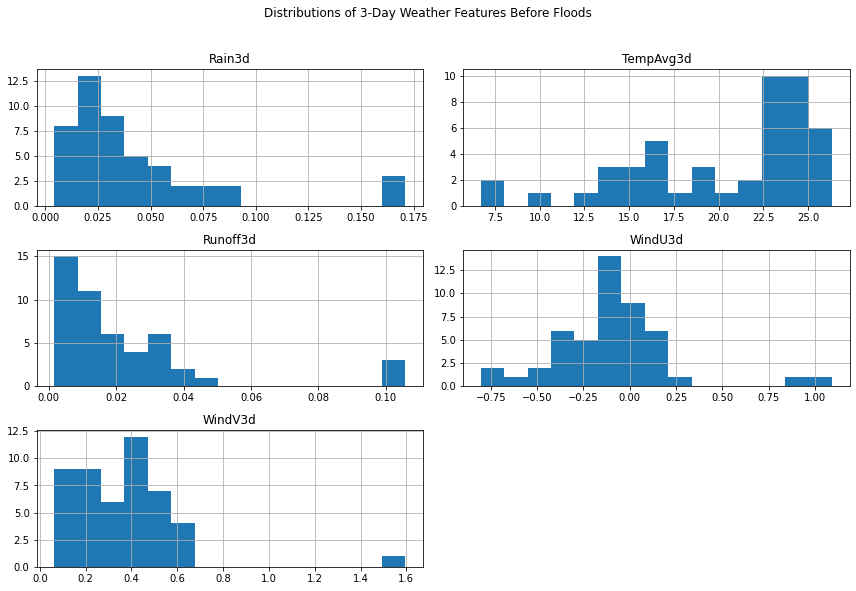

In [17]:
# 📊 Quick histograms of each weather variable

flood_geo_with_weather[["Rain3d", "TempAvg3d", "Runoff3d", "WindU3d", "WindV3d"]].hist(figsize=(12, 8), bins=15)
plt.suptitle("Distributions of 3-Day Weather Features Before Floods", y=1.02)
plt.tight_layout()
plt.show()


In [20]:
# 🎯 Create random non-flood control samples near flood locations, avoiding flood days ±3 days
import numpy as np
import pandas as pd

flood_locations = flood_df[["Latitude", "Longitude", "Date"]].dropna().copy()
flood_locations["Date"] = pd.to_datetime(flood_locations["Date"]).dt.tz_localize("Asia/Thimphu")

era_date_range = era_df["datetime"].dt.floor("D").drop_duplicates().sort_values().reset_index(drop=True)

control_rows = []

for _, row in flood_locations.iterrows():
    lat = row["Latitude"]
    lon = row["Longitude"]
    
    valid_dates = era_df[
        (era_df["latitude"].between(lat - 0.25, lat + 0.25)) &
        (era_df["longitude"].between(lon - 0.25, lon + 0.25))
    ]["datetime"].dt.floor("D").drop_duplicates().unique()
    
    valid_dates = pd.to_datetime(valid_dates)
    
    # 🧠 Fix timezone localization error for datetime index
    if valid_dates.tz is None:
        valid_dates = valid_dates.tz_localize("Asia/Thimphu")
    else:
        valid_dates = valid_dates.tz_convert("Asia/Thimphu")

    excluded_range = pd.date_range(
        row["Date"] - pd.Timedelta(days=3),
        row["Date"] + pd.Timedelta(days=3),
        tz="Asia/Thimphu"
    )
    
    possible_dates = list(set(valid_dates) - set(excluded_range))
    
    if possible_dates:
        random_date = np.random.choice(possible_dates)
        control_rows.append({"Date": random_date, "Latitude": lat, "Longitude": lon})

control_df = pd.DataFrame(control_rows)
control_df["Label"] = 0  # Not a flood


TypeError: Already tz-aware, use tz_convert to convert.